In [35]:
import os
import cv2
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model

In [ ]:
TRAIN_PATH = r"archive/dataset/train"
VAL_PATH   = r"archive/dataset/val"

def load_paths(folder):
    paths = []

    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                paths.append(os.path.join(root, f))

    return paths


train_paths = load_paths(TRAIN_PATH)
val_paths = load_paths(VAL_PATH)

print("Train images:", len(train_paths))
print("Val images:", len(val_paths))

Train images: 1370
Val images: 340


In [37]:
if len(train_paths) == 0:
    raise ValueError("No training images found. Check dataset path!")

In [ ]:
IMG_SIZE = 128
SCALE = 4
BATCH_SIZE = min(4, len(train_paths)) 
EPOCHS = 5
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)

In [39]:
def preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    hr = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lr = cv2.resize(hr, (IMG_SIZE//SCALE, IMG_SIZE//SCALE))
    lr = cv2.resize(lr, (IMG_SIZE, IMG_SIZE))

    hr = hr / 127.5 - 1.0
    lr = lr / 127.5 - 1.0

    return lr, hr

In [49]:
def data_generator(paths, batch_size):
    paths = list(paths)

    while True:
        batch_size = min(batch_size, len(paths))
        batch = random.choices(paths, k=batch_size)

        lr_imgs, hr_imgs = [], []

        for p in batch:
            lr, hr = preprocess(p)
            lr_imgs.append(lr)
            hr_imgs.append(hr)

        yield np.array(lr_imgs), np.array(hr_imgs)

In [41]:
def show_images(lr, sr, hr):
    lr = (lr + 1)/2
    sr = (sr + 1)/2
    hr = (hr + 1)/2

    plt.figure(figsize=(12,4))

    for i, img in enumerate([lr, sr, hr]):
        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

In [50]:
#Basic GAN
def build_generator():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(64, 9, padding='same', activation='relu')(inp)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    out = layers.Conv2D(3, 5, padding='same', activation='tanh')(x)

    return Model(inp, out)

def build_discriminator():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(64, 3, strides=2, padding='same')(inp)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Flatten()(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    return Model(inp, out)

In [51]:
#SRGAN
def res_block(x):
    skip = x

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU()(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    return layers.add([skip, x])


def build_srgan():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(64, 9, padding='same')(inp)
    x = layers.PReLU()(x)

    skip = x

    for _ in range(4):
        x = res_block(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.add([x, skip])

    out = layers.Conv2D(3, 9, padding='same', activation='tanh')(x)

    return Model(inp, out)

In [52]:
#ESRGAN
def build_esrgan():
    inp = layers.Input((IMG_SIZE, IMG_SIZE, 3))

    x = layers.Conv2D(64, 3, padding='same')(inp)

    for _ in range(2):
        skip = x
        x = layers.Conv2D(64, 3, padding='same')(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.add([x, skip])

    x = layers.Conv2D(64, 3, padding='same')(x)
    out = layers.Conv2D(3, 3, padding='same')(x)

    return Model(inp, out)

In [58]:
def train_model(generator, discriminator, train_paths, name="Model"):

    gen_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
    disc_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

    gen_data = data_generator(train_paths, BATCH_SIZE)

    print(f"\n Training {name}...\n")

    for epoch in range(EPOCHS):

        lr, hr = next(gen_data)
        fake_hr = generator(lr, training=True)

        real = np.ones((len(lr), 1))
        fake = np.zeros((len(lr), 1))

        with tf.GradientTape() as tape:

            pred_real = discriminator(hr, training=True)
            pred_fake = discriminator(fake_hr, training=True)

            d_loss_real = tf.keras.losses.binary_crossentropy(real, pred_real)
            d_loss_fake = tf.keras.losses.binary_crossentropy(fake, pred_fake)

            d_loss = tf.reduce_mean(d_loss_real + d_loss_fake)

        d_grads = tape.gradient(d_loss, discriminator.trainable_variables)

        d_grads = [
            g if g is not None else tf.zeros_like(v)
            for g, v in zip(d_grads, discriminator.trainable_variables)
        ]

        disc_optimizer.apply_gradients(
            zip(d_grads, discriminator.trainable_variables)
        )

        with tf.GradientTape() as tape:

            fake_hr = generator(lr, training=True)
            pred = discriminator(fake_hr, training=False)

            pixel_loss = tf.reduce_mean(tf.square(hr - fake_hr))

            adv_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(real, pred)
            )

            g_loss = pixel_loss + 1e-3 * adv_loss

        g_grads = tape.gradient(g_loss, generator.trainable_variables)

        g_grads = [
            g if g is not None else tf.zeros_like(v)
            for g, v in zip(g_grads, generator.trainable_variables)
        ]

        gen_optimizer.apply_gradients(
            zip(g_grads, generator.trainable_variables)
        )

        print(f"{name} Epoch {epoch+1}/{EPOCHS} | "
              f"D: {d_loss.numpy():.4f} | "
              f"G: {g_loss.numpy():.4f}")

    return generator

In [59]:
gen_gan = train_model(build_generator(), build_discriminator(), train_paths, "GAN")

gen_srgan = train_model(build_srgan(), build_discriminator(), train_paths, "SRGAN")

gen_esrgan = train_model(build_esrgan(), build_discriminator(), train_paths, "ESRGAN")


 Training GAN...

GAN Epoch 1/5 | D: 1.3720 | G: 0.3254
GAN Epoch 2/5 | D: 1.2157 | G: 0.2714
GAN Epoch 3/5 | D: 1.0905 | G: 0.3053
GAN Epoch 4/5 | D: 1.0225 | G: 0.2958
GAN Epoch 5/5 | D: 0.9942 | G: 0.2113

 Training SRGAN...

SRGAN Epoch 1/5 | D: 1.3737 | G: 1.0103
SRGAN Epoch 2/5 | D: 1.2765 | G: 0.5920
SRGAN Epoch 3/5 | D: 1.2688 | G: 0.4964
SRGAN Epoch 4/5 | D: 1.2643 | G: 0.3792
SRGAN Epoch 5/5 | D: 1.2664 | G: 0.3999

 Training ESRGAN...

ESRGAN Epoch 1/5 | D: 1.4092 | G: 0.3930
ESRGAN Epoch 2/5 | D: 1.2961 | G: 0.2803
ESRGAN Epoch 3/5 | D: 1.2389 | G: 0.1501
ESRGAN Epoch 4/5 | D: 1.2917 | G: 0.0617
ESRGAN Epoch 5/5 | D: 1.3173 | G: 0.1054


1/1 [==============================] - 0s 65ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.039930344..0.92371595].


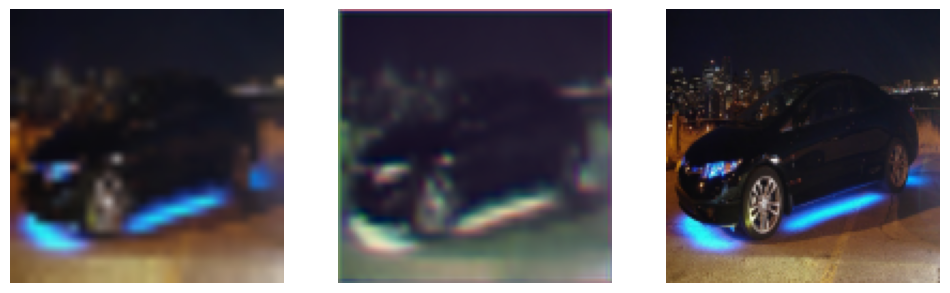

In [60]:
lr, hr = preprocess(val_paths[0])
lr_in = np.expand_dims(lr, axis=0)

sr = gen_esrgan.predict(lr_in)[0]

show_images(lr, sr, hr)